# Trading Pipeline Lineage — OpenMetadata Demo

Builds a five-table synthetic trading pipeline on Iceberg, then registers every table
and all data-flow edges in OpenMetadata so the complete lineage graph is visible in the UI.

**Pipeline**
```
raw_trades ──────┐
                 ├──▶ enriched_trades ──▶ daily_pnl ──▶ risk_report
raw_instruments ─┘
```

**Stack:** SeaweedFS (S3) → Polaris (Iceberg REST catalog) → Trino (SQL) → OpenMetadata (lineage)

**Running from JupyterHub (in-cluster):** no port-forward needed.

**Running locally:** start two port-forwards first:
```bash
kubectl port-forward -n lakehouse svc/trino        8080:8080
kubectl port-forward -n lakehouse svc/openmetadata 8585:8585
```
Then set `TRINO_HOST = 'localhost'` and `OM_HOST = 'localhost'` in the cell below.

In [12]:
%pip install trino pandas numpy requests networkx matplotlib --quiet


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Connect to Trino and OpenMetadata

In [1]:
import trino
import pandas as pd
import numpy as np
import requests
import base64
from datetime import datetime, timedelta
import random
import warnings
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 4)

# ── connection settings ──────────────────────────────────────────────────────
TRINO_HOST = 'localhost' # 'trino.lakehouse.svc.cluster.local'        # change to 'localhost' if running locally
TRINO_PORT = 8080
OM_HOST    =  'localhost' #'openmetadata.lakehouse.svc.cluster.local' # change to 'localhost' if running locally
OM_PORT    = 8585
OM_API     = f'http://{OM_HOST}:{OM_PORT}/api'
OM_EMAIL   = 'admin@open-metadata.org'
OM_PASS    = 'admin'   # change if your deployment uses a different password

CATALOG = 'prod'
SCHEMA  = 'risk'
OM_SVC  = 'quarry-lake-prod'
S3_BUCKET  = "shared-lake-bucket"  # CATALOG_prod_BUCKET in env/rsch-lake.mk

# ── Keycloak JWT auth ────────────────────────────────────────────────────────
# Port-forward: kubectl port-forward -n auth svc/keycloak-keycloakx-http 8090:80
# In-cluster URL would be: http://keycloak-keycloakx-http.auth.svc.cluster.local/auth
KEYCLOAK_URL   = 'http://localhost:8090/auth'
KEYCLOAK_REALM = 'rsch-lake'
CLIENT_ID      = 'PositionService'
CLIENT_SECRET  = 'gNUiRyYesntJc0o1oOG15FkDhHHMk6X9'  # TODO: fill in before running

kc_resp = requests.post(
    f'{KEYCLOAK_URL}/realms/{KEYCLOAK_REALM}/protocol/openid-connect/token',
    data={
        'grant_type':    'client_credentials',
        'client_id':     CLIENT_ID,
        'client_secret': CLIENT_SECRET,
    },
    timeout=10,
)
kc_resp.raise_for_status()
TOKEN = kc_resp.json()['access_token']
print(f'Token obtained for {CLIENT_ID} (expires_in={kc_resp.json()["expires_in"]}s)')

# ── Trino ────────────────────────────────────────────────────────────────────
conn = trino.dbapi.connect(
    host=TRINO_HOST, port=TRINO_PORT,
    user=CLIENT_ID,   # fallback identity; JWT preferred_username overrides when token is valid
    catalog=CATALOG, schema=SCHEMA, http_scheme='http',
    auth=trino.auth.JWTAuthentication(TOKEN),
)

def q(sql, fetch=True):
    cur = conn.cursor()
    cur.execute(sql)
    if fetch:
        cols = [d[0] for d in cur.description]
        return pd.DataFrame(cur.fetchall(), columns=cols)
    cur.fetchall()
    return None

version = q('SELECT version()').iloc[0, 0]
user    = q('SELECT current_user').iloc[0, 0]
print(f'Trino {version} — connected as {user}')

# ── OpenMetadata auth ────────────────────────────────────────────────────────
resp = requests.post(
    f'{OM_API}/v1/users/login',
    json={'email': OM_EMAIL, 'password': base64.b64encode(OM_PASS.encode()).decode()},
)
resp.raise_for_status()
om_token = resp.json()['accessToken']
om = requests.Session()
om.headers.update({
    'Authorization': f'Bearer {om_token}',
    'Content-Type':  'application/json',
})
print('OpenMetadata — authenticated.')

Token obtained for PositionService (expires_in=300s)
Trino 480 — connected as PositionService
OpenMetadata — authenticated.


## 2. Create Schema and Tables

In [2]:
q(f"""
    CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}
    WITH (location = 's3://{S3_BUCKET}/{CATALOG}/{SCHEMA}/')
""", fetch=False)

tables_ddl = {
    'raw_trades': f'''
        CREATE TABLE IF NOT EXISTS {CATALOG}.{SCHEMA}.raw_trades (
            trade_id        VARCHAR        COMMENT 'Unique trade identifier',
            trade_timestamp TIMESTAMP(6)   COMMENT 'Execution timestamp',
            ticker          VARCHAR        COMMENT 'Instrument ticker',
            quantity        BIGINT         COMMENT 'Number of shares',
            price           DECIMAL(12,4)  COMMENT 'Execution price',
            trader_id       VARCHAR        COMMENT 'Trader identifier',
            side            VARCHAR        COMMENT 'BUY or SELL'
        ) WITH (format = 'PARQUET', partitioning = ARRAY['ticker'])
    ''',
    'raw_instruments': f'''
        CREATE TABLE IF NOT EXISTS {CATALOG}.{SCHEMA}.raw_instruments (
            ticker          VARCHAR  COMMENT 'Instrument ticker',
            instrument_name VARCHAR  COMMENT 'Full instrument name',
            sector          VARCHAR  COMMENT 'GICS sector',
            exchange        VARCHAR  COMMENT 'Primary exchange',
            currency        VARCHAR  COMMENT 'Trading currency'
        ) WITH (format = 'PARQUET')
    ''',
    'enriched_trades': f'''
        CREATE TABLE IF NOT EXISTS {CATALOG}.{SCHEMA}.enriched_trades (
            trade_id        VARCHAR        COMMENT 'Unique trade identifier',
            trade_timestamp TIMESTAMP(6)   COMMENT 'Execution timestamp',
            ticker          VARCHAR        COMMENT 'Instrument ticker',
            instrument_name VARCHAR        COMMENT 'Full instrument name',
            sector          VARCHAR        COMMENT 'GICS sector',
            exchange        VARCHAR        COMMENT 'Primary exchange',
            quantity        BIGINT         COMMENT 'Number of shares',
            price           DECIMAL(12,4)  COMMENT 'Execution price',
            notional        DECIMAL(18,4)  COMMENT 'Trade notional value',
            trader_id       VARCHAR        COMMENT 'Trader identifier',
            side            VARCHAR        COMMENT 'BUY or SELL'
        ) WITH (format = 'PARQUET', partitioning = ARRAY['ticker'])
    ''',
    'daily_pnl': f'''
        CREATE TABLE IF NOT EXISTS {CATALOG}.{SCHEMA}.daily_pnl (
            trade_date   DATE           COMMENT 'Trading date',
            ticker       VARCHAR        COMMENT 'Instrument ticker',
            trader_id    VARCHAR        COMMENT 'Trader identifier',
            total_bought DECIMAL(18,4)  COMMENT 'Total notional bought',
            total_sold   DECIMAL(18,4)  COMMENT 'Total notional sold',
            net_position BIGINT         COMMENT 'Net share position',
            realized_pnl DECIMAL(18,4)  COMMENT 'Realised P&L'
        ) WITH (format = 'PARQUET', partitioning = ARRAY['trade_date'])
    ''',
    'risk_report': f'''
        CREATE TABLE IF NOT EXISTS {CATALOG}.{SCHEMA}.risk_report (
            report_date         DATE           COMMENT 'Report date',
            ticker              VARCHAR        COMMENT 'Instrument ticker',
            total_exposure      DECIMAL(18,4)  COMMENT 'Absolute net exposure',
            max_trader_position BIGINT         COMMENT 'Largest single-trader position',
            position_count      BIGINT         COMMENT 'Number of active traders'
        ) WITH (format = 'PARQUET', partitioning = ARRAY['report_date'])
    ''',
}

for name, ddl in tables_ddl.items():
    q(ddl, fetch=False)
    print(f'  {name} — ready')

  raw_trades — ready
  raw_instruments — ready
  enriched_trades — ready
  daily_pnl — ready
  risk_report — ready


## 3. Generate and Load Raw Data

In [3]:
INSTRUMENTS = [
    ('AAPL',  'Apple Inc.',               'Technology',        'NASDAQ', 'USD'),
    ('MSFT',  'Microsoft Corporation',    'Technology',        'NASDAQ', 'USD'),
    ('GOOGL', 'Alphabet Inc.',            'Communication',     'NASDAQ', 'USD'),
    ('AMZN',  'Amazon.com Inc.',          'Consumer Cyclical', 'NASDAQ', 'USD'),
    ('META',  'Meta Platforms Inc.',      'Communication',     'NASDAQ', 'USD'),
    ('NVDA',  'NVIDIA Corporation',       'Technology',        'NASDAQ', 'USD'),
    ('JPM',   'JPMorgan Chase and Co.',   'Financials',        'NYSE',   'USD'),
    ('GS',    'Goldman Sachs Group Inc.', 'Financials',        'NYSE',   'USD'),
]

BASE_PRICES = {
    'AAPL': 182, 'MSFT': 375, 'GOOGL': 140, 'AMZN': 153,
    'META': 350, 'NVDA': 495, 'JPM':   197, 'GS':   390,
}

TICKERS = list(BASE_PRICES.keys())
TRADERS = [f'TRADER_{i:03d}' for i in range(1, 11)]
START   = datetime(2024, 1, 2, 9, 30, 0)

N_TRADES = 2000
trades = []
for i in range(N_TRADES):
    ticker = random.choice(TICKERS)
    ts     = START + timedelta(
        days=random.randint(0, 29),
        hours=random.randint(0, 6),
        minutes=random.randint(0, 59),
        seconds=random.randint(0, 59),
    )
    trades.append({
        'trade_id':        f'TRADE_{i+1:06d}',
        'trade_timestamp': ts.strftime('%Y-%m-%d %H:%M:%S'),
        'ticker':          ticker,
        'quantity':        random.randint(100, 5000),
        'price':           round(BASE_PRICES[ticker] * random.uniform(0.97, 1.03), 4),
        'trader_id':       random.choice(TRADERS),
        'side':            random.choice(['BUY', 'SELL']),
    })

trades_df = pd.DataFrame(trades)
print(f'Generated {len(trades_df):,} trades across {trades_df["ticker"].nunique()} tickers')
trades_df.head(3)

Generated 2,000 trades across 8 tickers


,trade_id,trade_timestamp,ticker,quantity,price,trader_id,side
0,TRADE_000001,2024-01-02 14:47:15,MSFT,1928,366.8896,TRADER_002,BUY
1,TRADE_000002,2024-01-03 09:35:13,JPM,2005,197.0633,TRADER_001,BUY
2,TRADE_000003,2024-01-09 13:07:17,JPM,153,200.0591,TRADER_003,SELL


In [4]:
# ── raw_instruments (8 rows) ──────────────────────────────────────────────────
inst_vals = ', '.join(
    f"('{t}', '{n}', '{s}', '{e}', '{c}')"
    for t, n, s, e, c in INSTRUMENTS
)
q(f'INSERT INTO {CATALOG}.{SCHEMA}.raw_instruments VALUES {inst_vals}', fetch=False)
print(f'Loaded {len(INSTRUMENTS)} instruments.')

# ── raw_trades (batched) ──────────────────────────────────────────────────────
def insert_trades(df, batch_size=250):
    cur   = conn.cursor()
    total = len(df)
    done  = 0
    for start in range(0, total, batch_size):
        batch = df.iloc[start:start+batch_size]
        vals  = ', '.join(
            f"('{r.trade_id}', TIMESTAMP '{r.trade_timestamp}', '{r.ticker}',"
            f" BIGINT '{r.quantity}', DECIMAL '{r.price}', '{r.trader_id}', '{r.side}')"
            for r in batch.itertuples()
        )
        cur.execute(f'INSERT INTO {CATALOG}.{SCHEMA}.raw_trades VALUES {vals}')
        cur.fetchall()
        done += len(batch)
        print(f'  {done:>5}/{total} trades', end='\r')
    print(f'  {done:>5}/{total} trades — done.')

print(f'Loading {len(trades_df):,} trades ...')
insert_trades(trades_df)
print('Raw data loaded.')

Loaded 8 instruments.
Loading 2,000 trades ...
   2000/2000 trades — done.
Raw data loaded.


## 4. Build Derived Tables

Each SQL step is one hop in the lineage graph that we will register in OpenMetadata.

In [5]:
# raw_trades + raw_instruments ──▶ enriched_trades
q(f'''
    INSERT INTO {CATALOG}.{SCHEMA}.enriched_trades
    SELECT
        t.trade_id,
        t.trade_timestamp,
        t.ticker,
        i.instrument_name,
        i.sector,
        i.exchange,
        t.quantity,
        t.price,
        CAST(t.quantity AS DECIMAL(18,4)) * CAST(t.price AS DECIMAL(18,4)) AS notional,
        t.trader_id,
        t.side
    FROM {CATALOG}.{SCHEMA}.raw_trades      AS t
    JOIN {CATALOG}.{SCHEMA}.raw_instruments AS i ON t.ticker = i.ticker
''', fetch=False)

cnt = q(f'SELECT COUNT(*) AS c FROM {CATALOG}.{SCHEMA}.enriched_trades').iloc[0,0]
print(f'enriched_trades: {cnt:,} rows')

enriched_trades: 10,000 rows


In [6]:
# enriched_trades ──▶ daily_pnl
q(f'''
    INSERT INTO {CATALOG}.{SCHEMA}.daily_pnl
    SELECT
        CAST(trade_timestamp AS DATE)                                              AS trade_date,
        ticker,
        trader_id,
        SUM(CASE WHEN side = 'BUY'  THEN notional ELSE CAST(0 AS DECIMAL(18,4)) END) AS total_bought,
        SUM(CASE WHEN side = 'SELL' THEN notional ELSE CAST(0 AS DECIMAL(18,4)) END) AS total_sold,
        SUM(CASE WHEN side = 'BUY'  THEN quantity  ELSE -quantity END)             AS net_position,
        SUM(CASE WHEN side = 'SELL' THEN notional  ELSE -notional END)             AS realized_pnl
    FROM {CATALOG}.{SCHEMA}.enriched_trades
    GROUP BY CAST(trade_timestamp AS DATE), ticker, trader_id
''', fetch=False)

cnt = q(f'SELECT COUNT(*) AS c FROM {CATALOG}.{SCHEMA}.daily_pnl').iloc[0,0]
print(f'daily_pnl: {cnt:,} rows')

daily_pnl: 2,734 rows


In [7]:
# daily_pnl ──▶ risk_report
q(f'''
    INSERT INTO {CATALOG}.{SCHEMA}.risk_report
    SELECT
        trade_date                          AS report_date,
        ticker,
        SUM(ABS(total_bought - total_sold)) AS total_exposure,
        MAX(ABS(net_position))              AS max_trader_position,
        COUNT(DISTINCT trader_id)           AS position_count
    FROM {CATALOG}.{SCHEMA}.daily_pnl
    GROUP BY trade_date, ticker
''', fetch=False)

cnt = q(f'SELECT COUNT(*) AS c FROM {CATALOG}.{SCHEMA}.risk_report').iloc[0,0]
print(f'risk_report: {cnt:,} rows')

risk_report: 480 rows


In [8]:
# Row counts across all five tables
for name in ['raw_trades', 'raw_instruments', 'enriched_trades', 'daily_pnl', 'risk_report']:
    cnt = q(f'SELECT COUNT(*) AS c FROM {CATALOG}.{SCHEMA}.{name}').iloc[0,0]
    print(f'  {name:25s} {cnt:>6,} rows')

  raw_trades                 4,000 rows
  raw_instruments               16 rows
  enriched_trades           10,000 rows
  daily_pnl                  2,734 rows
  risk_report                  480 rows


## 5. Register Tables in OpenMetadata

We use OpenMetadata's REST API directly — no extra SDK needed.
Each `PUT` call is an upsert, so re-running this notebook is safe.

In [9]:
def om_put(path, payload):
    resp = om.put(f'{OM_API}/v1/{path}', json=payload)
    if not resp.ok:
        raise RuntimeError(f'PUT {path} → {resp.status_code}: {resp.text[:400]}')
    return resp.json()

def om_get_fqn(entity_type, fqn):
    resp = om.get(f'{OM_API}/v1/{entity_type}/name/{fqn}')
    if resp.status_code == 404:
        return None
    resp.raise_for_status()
    return resp.json()

# 1. Database service
svc = om_put('services/databaseServices', {
    'name':        OM_SVC,
    'displayName': 'Trino Lakehouse',
    'serviceType': 'Trino',
    'connection': {
        'config': {
            'type':     'Trino',
            'hostPort': f'{TRINO_HOST}:{TRINO_PORT}',
            'username': 'admin',
        }
    },
})
print(f'Service  : {svc["fullyQualifiedName"]}')

# 2. Database
db = om_put('databases', {
    'name':    CATALOG,
    'service': OM_SVC,
})
print(f'Database : {db["fullyQualifiedName"]}')

# 3. Schema
dbschema = om_put('databaseSchemas', {
    'name':     SCHEMA,
    'database': f'{OM_SVC}.{CATALOG}',
})
print(f'Schema   : {dbschema["fullyQualifiedName"]}')

Service  : quarry-lake-prod
Database : quarry-lake-prod.prod
Schema   : quarry-lake-prod.prod.risk


In [10]:
TABLE_COLUMNS = {
    'raw_trades': [
        {'name': 'trade_id',        'dataType': 'VARCHAR',   'dataLength': 256, 'description': 'Unique trade identifier'},
        {'name': 'trade_timestamp', 'dataType': 'TIMESTAMP', 'description': 'Execution timestamp'},
        {'name': 'ticker',          'dataType': 'VARCHAR',   'dataLength': 16,  'description': 'Instrument ticker'},
        {'name': 'quantity',        'dataType': 'BIGINT',    'description': 'Number of shares'},
        {'name': 'price',           'dataType': 'DECIMAL',   'description': 'Execution price'},
        {'name': 'trader_id',       'dataType': 'VARCHAR',   'dataLength': 64,  'description': 'Trader identifier'},
        {'name': 'side',            'dataType': 'VARCHAR',   'dataLength': 8,   'description': 'BUY or SELL'},
    ],
    'raw_instruments': [
        {'name': 'ticker',          'dataType': 'VARCHAR', 'dataLength': 16,  'description': 'Instrument ticker'},
        {'name': 'instrument_name', 'dataType': 'VARCHAR', 'dataLength': 256, 'description': 'Full instrument name'},
        {'name': 'sector',          'dataType': 'VARCHAR', 'dataLength': 64,  'description': 'GICS sector'},
        {'name': 'exchange',        'dataType': 'VARCHAR', 'dataLength': 32,  'description': 'Primary exchange'},
        {'name': 'currency',        'dataType': 'VARCHAR', 'dataLength': 8,   'description': 'Trading currency'},
    ],
    'enriched_trades': [
        {'name': 'trade_id',        'dataType': 'VARCHAR',   'dataLength': 256, 'description': 'Unique trade identifier'},
        {'name': 'trade_timestamp', 'dataType': 'TIMESTAMP', 'description': 'Execution timestamp'},
        {'name': 'ticker',          'dataType': 'VARCHAR',   'dataLength': 16,  'description': 'Instrument ticker'},
        {'name': 'instrument_name', 'dataType': 'VARCHAR',   'dataLength': 256, 'description': 'From raw_instruments'},
        {'name': 'sector',          'dataType': 'VARCHAR',   'dataLength': 64,  'description': 'From raw_instruments'},
        {'name': 'exchange',        'dataType': 'VARCHAR',   'dataLength': 32,  'description': 'From raw_instruments'},
        {'name': 'quantity',        'dataType': 'BIGINT',    'description': 'Number of shares'},
        {'name': 'price',           'dataType': 'DECIMAL',   'description': 'Execution price'},
        {'name': 'notional',        'dataType': 'DECIMAL',   'description': 'Trade notional value'},
        {'name': 'trader_id',       'dataType': 'VARCHAR',   'dataLength': 64,  'description': 'Trader identifier'},
        {'name': 'side',            'dataType': 'VARCHAR',   'dataLength': 8,   'description': 'BUY or SELL'},
    ],
    'daily_pnl': [
        {'name': 'trade_date',   'dataType': 'DATE',    'description': 'Trading date'},
        {'name': 'ticker',       'dataType': 'VARCHAR', 'dataLength': 16, 'description': 'Instrument ticker'},
        {'name': 'trader_id',    'dataType': 'VARCHAR', 'dataLength': 64, 'description': 'Trader identifier'},
        {'name': 'total_bought', 'dataType': 'DECIMAL', 'description': 'Total notional bought'},
        {'name': 'total_sold',   'dataType': 'DECIMAL', 'description': 'Total notional sold'},
        {'name': 'net_position', 'dataType': 'BIGINT',  'description': 'Net share position'},
        {'name': 'realized_pnl', 'dataType': 'DECIMAL', 'description': 'Realised P&L'},
    ],
    'risk_report': [
        {'name': 'report_date',         'dataType': 'DATE',    'description': 'Report date'},
        {'name': 'ticker',              'dataType': 'VARCHAR', 'dataLength': 16, 'description': 'Instrument ticker'},
        {'name': 'total_exposure',      'dataType': 'DECIMAL', 'description': 'Absolute net exposure'},
        {'name': 'max_trader_position', 'dataType': 'BIGINT',  'description': 'Largest single-trader position'},
        {'name': 'position_count',      'dataType': 'BIGINT',  'description': 'Number of active traders'},
    ],
}

schema_fqn = f'{OM_SVC}.{CATALOG}.{SCHEMA}'
table_ids  = {}

for tbl_name, columns in TABLE_COLUMNS.items():
    entity = om_put('tables', {
        'name':           tbl_name,
        'databaseSchema': schema_fqn,
        'tableType':      'Regular',
        'columns':        columns,
    })
    table_ids[tbl_name] = entity['id']
    print(f'  {tbl_name:25s} registered  (id {entity["id"][:8]}…)')

  raw_trades                registered  (id d9324472…)
  raw_instruments           registered  (id b3492864…)
  enriched_trades           registered  (id cc71a158…)
  daily_pnl                 registered  (id ec877e4a…)
  risk_report               registered  (id 5efeee57…)


## 6. Register Lineage Edges

## 6a. Register PositionService as a Pipeline (data producer)

OpenMetadata lineage edges can connect any combination of entity types — not just tables.
`Pipeline` entities represent processes that produce or consume data and appear as nodes in the lineage graph.

Here we register **PositionService** (the Keycloak-authenticated service that writes the raw tables)
as a `CustomPipeline` and link it upstream of `raw_trades` and `raw_instruments`.

In [12]:
# 1. Pipeline service (CustomPipeline — one service can hold many pipeline entities)
pipeline_svc = om_put('services/pipelineServices', {
    'name':        'position-service',
    'displayName': 'Position Service',
    'serviceType': 'CustomPipeline',
    'connection':  {'config': {'type': 'CustomPipeline'}},
})
print(f'Pipeline service : {pipeline_svc["fullyQualifiedName"]}')

# 2. Pipeline entity representing the PositionService process
pipeline = om_put('pipelines', {
    'name':        'PositionService',
    'displayName': 'Position Service',
    'description': (
        'Keycloak-authenticated service that computes and writes model desired positions, '
        'RTM positions, and expected positions into the prod catalog via Trino.'
    ),
    'service':     pipeline_svc['fullyQualifiedName'],
})
pipeline_id = pipeline['id']
print(f'Pipeline entity  : {pipeline["fullyQualifiedName"]}  (id {pipeline_id[:8]}…)')

# 3. Lineage edges: PositionService ──▶ raw_trades, raw_instruments
for tbl in ('raw_trades', 'raw_instruments'):
    resp = om.put(f'{OM_API}/v1/lineage', json={
        'edge': {
            'fromEntity': {'id': pipeline_id,         'type': 'pipeline'},
            'toEntity':   {'id': table_ids[tbl],      'type': 'table'},
        }
    })
    if not resp.ok:
        raise RuntimeError(f'PositionService -> {tbl}: {resp.status_code}: {resp.text[:200]}')
    print(f'  PositionService ──▶  {tbl}')

print('\nPositionService registered and linked.')

Pipeline service : position-service
Pipeline entity  : position-service.PositionService  (id 2633928f…)
  PositionService ──▶  raw_trades
  PositionService ──▶  raw_instruments

PositionService registered and linked.


In [13]:
LINEAGE_EDGES = [
    ('raw_trades',      'enriched_trades'),
    ('raw_instruments', 'enriched_trades'),
    ('enriched_trades', 'daily_pnl'),
    ('daily_pnl',       'risk_report'),
]

def add_lineage(from_table, to_table):
    payload = {
        'edge': {
            'fromEntity': {'id': table_ids[from_table], 'type': 'table'},
            'toEntity':   {'id': table_ids[to_table],   'type': 'table'},
        }
    }
    resp = om.put(f'{OM_API}/v1/lineage', json=payload)
    if not resp.ok:
        raise RuntimeError(f'{from_table} -> {to_table}: {resp.status_code}: {resp.text[:200]}')
    # lineage endpoint returns an empty body on success

for src, dst in LINEAGE_EDGES:
    add_lineage(src, dst)
    print(f'  {src:25s} ──▶  {dst}')

print('\nAll lineage edges registered.')

  raw_trades                ──▶  enriched_trades
  raw_instruments           ──▶  enriched_trades
  enriched_trades           ──▶  daily_pnl
  daily_pnl                 ──▶  risk_report

All lineage edges registered.


## 7. Inspect Lineage

Query the lineage graph back from OpenMetadata, print the edges, and draw the DAG.

In [14]:
# Query lineage centred on enriched_trades (3 hops upstream, 3 hops downstream)
pivot_id = table_ids['enriched_trades']
resp = om.get(
    f'{OM_API}/v1/lineage/table/{pivot_id}',
    params={'upstreamDepth': 3, 'downstreamDepth': 3},
)
resp.raise_for_status()
lineage = resp.json()

# Build id → name lookup from the response
id_to_name = {n['id']: n['name'] for n in lineage.get('nodes', [])}
id_to_name[lineage['entity']['id']] = lineage['entity']['name']

all_edges = lineage.get('upstreamEdges', []) + lineage.get('downstreamEdges', [])

print('Nodes:', sorted(id_to_name.values()))
print('\nEdges:')
for e in all_edges:
    src = id_to_name.get(e['fromEntity'], e['fromEntity'])
    dst = id_to_name.get(e['toEntity'],   e['toEntity'])
    print(f'  {src:25s} ──▶  {dst}')

Nodes: ['PositionService', 'daily_pnl', 'enriched_trades', 'raw_instruments', 'raw_trades', 'risk_report']

Edges:
  raw_instruments           ──▶  enriched_trades
  raw_trades                ──▶  enriched_trades
  PositionService           ──▶  raw_instruments
  PositionService           ──▶  raw_trades
  enriched_trades           ──▶  daily_pnl
  daily_pnl                 ──▶  risk_report


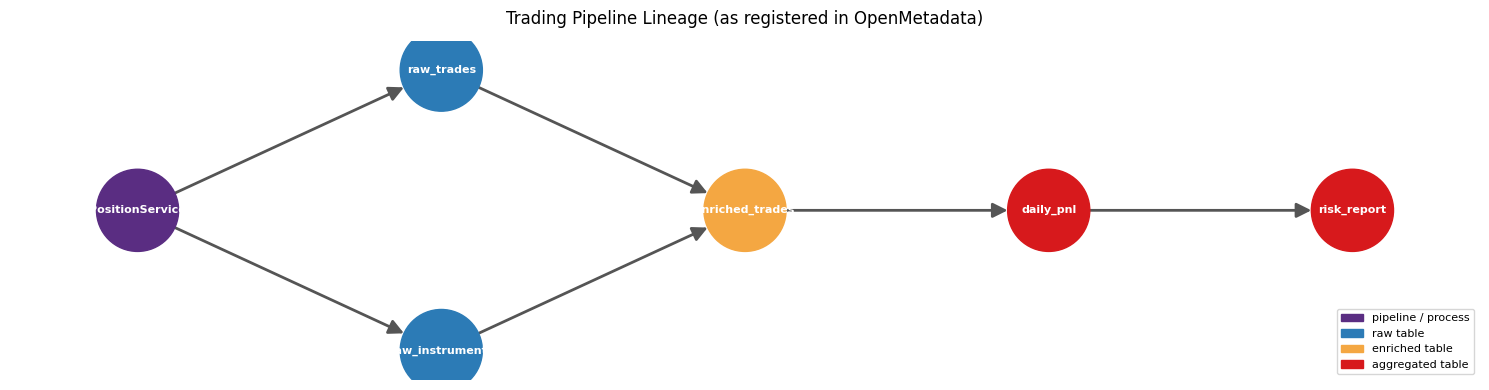

In [15]:
G = nx.DiGraph()
for e in all_edges:
    src = id_to_name.get(e['fromEntity'], e['fromEntity'])
    dst = id_to_name.get(e['toEntity'],   e['toEntity'])
    G.add_edge(src, dst)

pos = {
    'PositionService':  (-2,  0.0),
    'raw_trades':       ( 0,  1.0),
    'raw_instruments':  ( 0, -1.0),
    'enriched_trades':  ( 2,  0.0),
    'daily_pnl':        ( 4,  0.0),
    'risk_report':      ( 6,  0.0),
}

def node_color(n):
    if n == 'PositionService':  return '#5a2d82'  # purple — pipeline/process
    if n.startswith('raw'):     return '#2c7bb6'  # blue   — raw tables
    if n == 'enriched_trades':  return '#f4a742'  # orange — enriched
    return '#d7191c'                              # red    — aggregated

node_colors = [node_color(n) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(15, 4))
nx.draw_networkx(
    G, pos, ax=ax,
    node_color=node_colors,
    node_size=3500,
    font_size=8,
    font_color='white',
    font_weight='bold',
    edge_color='#555555',
    arrows=True,
    arrowsize=22,
    width=2,
)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#5a2d82', label='pipeline / process'),
    Patch(color='#2c7bb6', label='raw table'),
    Patch(color='#f4a742', label='enriched table'),
    Patch(color='#d7191c', label='aggregated table'),
]
ax.legend(handles=legend, loc='lower right', fontsize=8)
ax.set_title('Trading Pipeline Lineage (as registered in OpenMetadata)', fontsize=12, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Cleanup (optional)

Uncomment and run each cell to tear down the resources created by this notebook.

In [15]:
# Uncomment to drop all Trino tables and the schema.
# for name in ['risk_report', 'daily_pnl', 'enriched_trades', 'raw_instruments', 'raw_trades']:
#     q(f'DROP TABLE IF EXISTS {CATALOG}.{SCHEMA}.{name}', fetch=False)
# q(f'DROP SCHEMA IF EXISTS {CATALOG}.{SCHEMA}', fetch=False)
# print('Trino tables and schema dropped.')

In [ ]:
# Uncomment to remove OpenMetadata entities (tables, schema, database, service, pipeline).
# for tbl_id in table_ids.values():
#     om.delete(f'{OM_API}/v1/tables/{tbl_id}?hardDelete=true&recursive=true')
# schema_ent = om_get_fqn('databaseSchemas', f'{OM_SVC}.{CATALOG}.{SCHEMA}')
# if schema_ent:
#     om.delete(f'{OM_API}/v1/databaseSchemas/{schema_ent["id"]}?hardDelete=true&recursive=true')
# db_ent = om_get_fqn('databases', f'{OM_SVC}.{CATALOG}')
# if db_ent:
#     om.delete(f'{OM_API}/v1/databases/{db_ent["id"]}?hardDelete=true&recursive=true')
# svc_ent = om_get_fqn('services/databaseServices', OM_SVC)
# if svc_ent:
#     om.delete(f'{OM_API}/v1/services/databaseServices/{svc_ent["id"]}?hardDelete=true&recursive=true')
# pipeline_ent = om_get_fqn('pipelines', f'position-service.PositionService')
# if pipeline_ent:
#     om.delete(f'{OM_API}/v1/pipelines/{pipeline_ent["id"]}?hardDelete=true&recursive=true')
# pipeline_svc_ent = om_get_fqn('services/pipelineServices', 'position-service')
# if pipeline_svc_ent:
#     om.delete(f'{OM_API}/v1/services/pipelineServices/{pipeline_svc_ent["id"]}?hardDelete=true&recursive=true')
# print('OpenMetadata entities removed.')